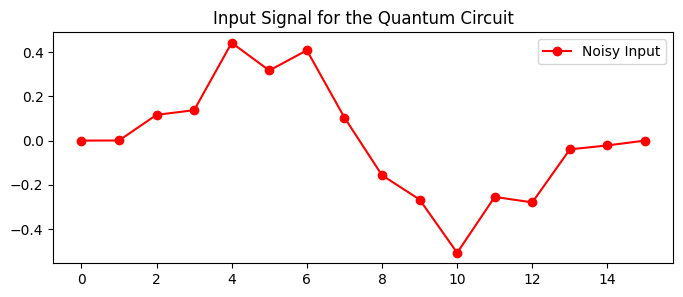

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


N = 16
n_qubits = int(np.log2(N))
x = np.linspace(0, 1, N)

# Signal = Low freq, Noise = High freq
clean_signal = np.sin(2 * np.pi * x)
noise = 0.4 * np.cos(8 * 2 * np.pi * x)
window = np.hanning(N)
noisy_signal = (clean_signal + noise) * window

# Normalize for quantum state preparation
initial_state = noisy_signal / np.linalg.norm(noisy_signal)

plt.figure(figsize=(8, 3))
plt.plot(initial_state, 'r-o', label="Noisy Input")
plt.title("Input Signal for the Quantum Circuit")
plt.legend()
plt.show()

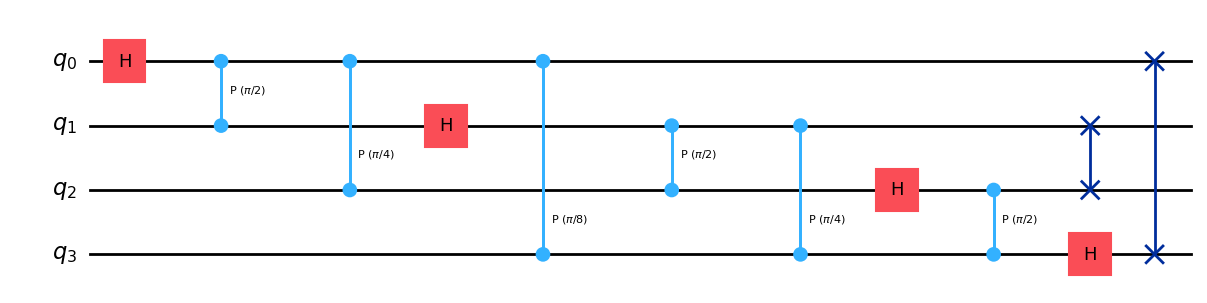

In [2]:
def build_qft(n):
    qc = QuantumCircuit(n, name="QFT_Scratch")
    for i in range(n):
        qc.h(i)
        for j in range(i + 1, n):
            angle = np.pi / (2**(j - i))
            qc.cp(angle, j, i)
    
    # Correcting for Qiskit bit-ordering
    for i in range(n // 2):
        qc.swap(i, n - i - 1)
    return qc

# Visualize the QFT component
qft_component = build_qft(n_qubits)
qft_component.draw('mpl')

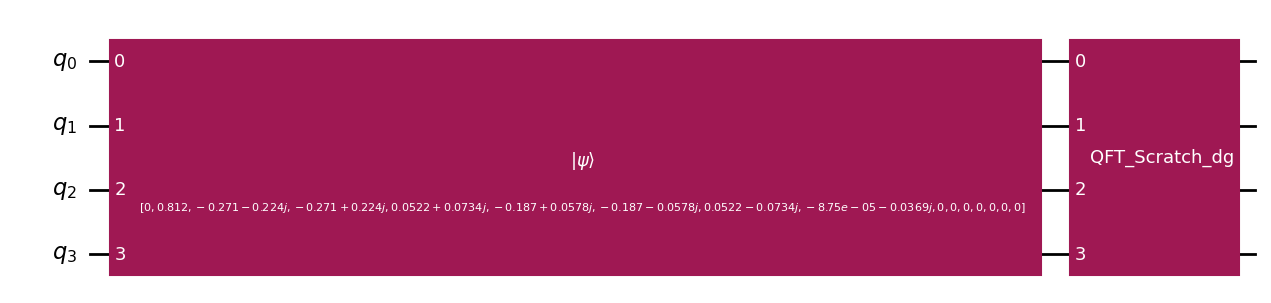

In [3]:
from qiskit.quantum_info import Statevector

# --- STEP 1: Forward Pass ---
# Create a circuit just for loading data and moving to Frequency Domain
forward_qc = QuantumCircuit(n_qubits)
forward_qc.initialize(initial_state, range(n_qubits))
forward_qc.append(qft_component, range(n_qubits))

# Execute to get the 'Frequency Domain' state
freq_state = Statevector(forward_qc)

# --- STEP 2: The Filter (Manual Surgery) ---
# We apply the mask directly to the data array of the statevector
freq_data = freq_state.data
filter_mask = np.array([1]*9 + [0]*7) 
filter_matrix = np.diag(filter_mask)
filtered_freq_data = freq_data * filter_mask

# Create a new Statevector from this filtered data
# (Note: This state is no longer normalized, which is fine for filtering)
filtered_freq_state = Statevector(filtered_freq_data)

# --- STEP 3: Backward Pass ---
# Create a circuit for the Inverse QFT
inverse_qc = QuantumCircuit(n_qubits)
inverse_qc.initialize(filtered_freq_state, range(n_qubits),normalize=True)
inverse_qc.append(qft_component.inverse(), range(n_qubits))

# Draw this part to see the Inverse QFT
inverse_qc.draw('mpl')

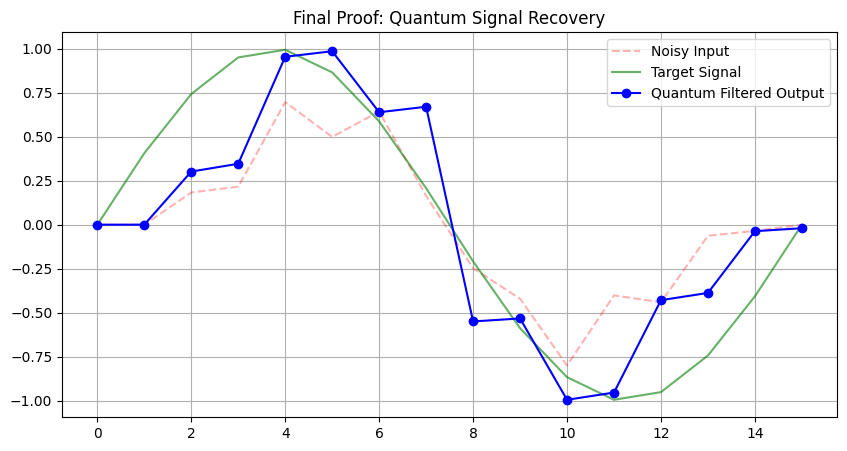

In [4]:
# Final simulation and plot
final_state = Statevector(inverse_qc)
filtered_output = np.real(final_state.data)

# Scale back to original signal magnitude for final comparison
filtered_output = filtered_output / np.max(np.abs(filtered_output))
filtered_output *= np.max(np.abs(clean_signal))

plt.figure(figsize=(10, 5))
plt.plot(noisy_signal, 'r--', alpha=0.3, label="Noisy Input")
plt.plot(clean_signal, 'g', label="Target Signal", alpha=0.6)
plt.plot(filtered_output, 'b-o', label="Quantum Filtered Output")
plt.title("Final Proof: Quantum Signal Recovery")
plt.legend()
plt.grid(True)
plt.show()